In [1]:
library(numbat)
library(dplyr)
library(Seurat)
library(data.table)
library(ggplot2)
library(dplyr)
library(glue)
library(ggtree)
library(stringr)
library(tidygraph)
library(patchwork)
library(gridExtra)
library(grid)
library(future)
plan("multicore", workers = 12)
options(future.globals.maxSize = 10000 * 1024^10,
        future.rng.onMisuse = 'ignore')
sessionInfo()

Loading required package: Matrix


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: SeuratObject

Loading required package: sp

The legacy packages maptools, rgdal, and rgeos, underpinning this package
will retire shortly. Please refer to R-spatial evolution reports on
https://r-spatial.org/r/2023/05/15/evolution4.html for details.
This package is now running under evolution status 0 


Attaching package: ‘SeuratObject’


The following object is masked from ‘package:base’:

    intersect



Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


ggtree v3.6.2 For help: https://yulab-smu.top/treedata-book/

If you use the ggtree package suite in published research, please cite
the appropriate paper(s):

Guangchuang Yu, David Smith, Huachen Zhu, Yi Guan,

R version 4.2.3 (2023-03-15)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Red Hat Enterprise Linux 8.6 (Ootpa)

Matrix products: default
BLAS/LAPACK: /gpfs/home3/cruiz2/miniconda3/envs/r_python/lib/libopenblasp-r0.3.21.so

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] future_1.32.0      gridExtra_2.3      patchwork_1.1.2    tidygraph_1.2.3   
 [5] stringr_1.5.0      ggtree_3.6.2       glue_1.6.2         ggplot2_3.4.2     
 [9] data.table_1.14.8  Seurat_5.0.1       SeuratObject_5.0.1 sp_1.6-1          
[13] dplyr_1.1.2     

In [2]:
dmg <- readRDS('/projects/0/einf2548/cruiz/dmg/data/merged_dmg_atlas_qc_filtered.rds')
dmg

An object of class Seurat 
38576 features across 409561 samples within 6 assays 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 5 other assays present: RAW, prediction.score.annotation_level_1, prediction.score.annotation_level_2, prediction.score.annotation_level_3, prediction.score.annotation_level_4
 4 dimensional reductions calculated: pca, umap, ref.pca, ref.umap

In [3]:
dmg <- subset(dmg, Batch_for_correction == '10Xv3_cell_rna')
dmg

An object of class Seurat 
38576 features across 57305 samples within 6 assays 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 5 other assays present: RAW, prediction.score.annotation_level_1, prediction.score.annotation_level_2, prediction.score.annotation_level_3, prediction.score.annotation_level_4
 4 dimensional reductions calculated: pca, umap, ref.pca, ref.umap

In [4]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,5070311,270.8,9908250,529.2,9908250,529.2
Vcells,853104815,6508.7,7275079900,55504.5,7486892291,57120.5


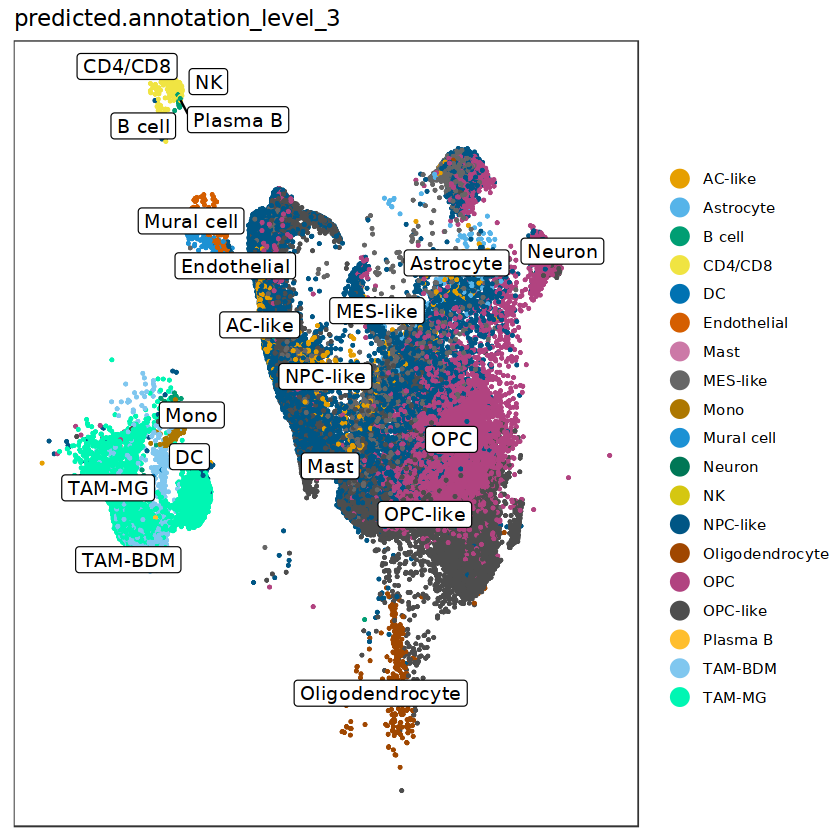

In [5]:
dittoSeq::dittoDimPlot(dmg, 
             reduction.use = "umap", var = "predicted.annotation_level_3", 
             do.label = T, labels.size = 4, 
             do.raster = TRUE) + NoAxes() 

In [6]:
samples <- names(table(dmg$SampleID))
samples <- gsub('_RNA_only', '', samples)
samples 

[1] "P-6117_S-8370" "P-6240_S-8628" "P-6328_S-8672" "P-6337_S-8821"
[5] "P-6519_S-9084"

In [7]:
options(warn = 0)

In [8]:
for(i in 1:length(samples)){

     nb = Numbat$new(out_dir = paste0('sc/', samples[i]))
    
    p <- nb$plot_consensus()
  
    pdf(file = paste0('figures/scRNA_', samples[i], "_icnv_concensus.pdf"), height = 0.5, width = 10)
    print(p)
    dev.off()
}

Warning message:
“ggrepel: 3 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 1 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 3 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 3 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 3 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 3 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 2 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 5 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 4 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 3 unlabeled data po